<a href="https://colab.research.google.com/github/awfajri/artificial-intelligence/blob/main/soal_2_UTS_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Soal UTS Kecerdasan Buatan no.1
<br>
Nama : Auf Fajri Ramadhani
<br>
NPM  : 2410631170059

install dan import library sikit-fuzzy

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.7 MB/s eta 0:00:00


LANGKAH 1: Membuat Variabel Input dan Output
            Menggunakan Antecedent dan Consequent

In [ ]:
berat_sampah = ctrl.Antecedent(np.arange(0, 1002, 1), 'berat_sampah')

kecepatan_motor = ctrl.Consequent(np.arange(0, 256, 1), 'kecepatan_motor')

print("=== Variabel Fuzzy Berhasil Dibuat ===")
print(f"  Input  (Antecedent) : berat_sampah   -> range 0 - 1001 gram")
print(f"  Output (Consequent) : kecepatan_motor -> range 0 - 255 PWM")

=== Variabel Fuzzy Berhasil Dibuat ===
  Input  (Antecedent) : berat_sampah   -> range 0 - 1001 gram
  Output (Consequent) : kecepatan_motor -> range 0 - 255 PWM


LANGKAH 2: Membuat Fungsi Keanggotaan untuk Variabel Sensor
            Berat dan Kecepatan Motor Menggunakan trimf

In [ ]:
# --- Fungsi Keanggotaan Berat Sampah ---
# Ringan : [0,   0,   400] -> puncak di 0, turun sampai 400
# Sedang : [300, 500, 700] -> naik dari 300, puncak di 500, turun ke 700
# Berat  : [600, 1001, 1001] -> naik dari 600, puncak di 1001

berat_sampah['ringan'] = fuzz.trimf(berat_sampah.universe, [0,    0,    400])
berat_sampah['sedang'] = fuzz.trimf(berat_sampah.universe, [300,  500,  700])
berat_sampah['berat']  = fuzz.trimf(berat_sampah.universe, [600,  1001, 1001])

# --- Fungsi Keanggotaan Kecepatan Motor ---
# Lambat : [0,   0,   100] -> puncak di 0, turun sampai 100
# Normal : [80,  130, 180] -> naik dari 80, puncak di 130, turun ke 180
# Cepat  : [160, 255, 255] -> naik dari 160, puncak di 255

kecepatan_motor['lambat'] = fuzz.trimf(kecepatan_motor.universe, [0,   0,   100])
kecepatan_motor['normal'] = fuzz.trimf(kecepatan_motor.universe, [80,  130, 180])
kecepatan_motor['cepat']  = fuzz.trimf(kecepatan_motor.universe, [160, 255, 255])

print("\n=== Fungsi Keanggotaan Berhasil Dibuat ===")
print("  Berat Sampah    : ringan [0-400], sedang [300-700], berat [600-1001]")
print("  Kecepatan Motor : lambat [0-100], normal [80-180], cepat [160-255]")


=== Fungsi Keanggotaan Berhasil Dibuat ===
  Berat Sampah    : ringan [0-400], sedang [300-700], berat [600-1001]
  Kecepatan Motor : lambat [0-100], normal [80-180], cepat [160-255]


LANGKAH 3: Membuat Aturan Fuzzy Menggunakan ctrl.Rule

In [ ]:
# Aturan kerja dari tim riset:
#   IF berat = Ringan -> THEN kecepatan = Cepat  (beban ringan, gerak cepat)
#   IF berat = Sedang -> THEN kecepatan = Normal (beban sedang, gerak normal)
#   IF berat = Berat  -> THEN kecepatan = Lambat (beban berat, gerak pelan)

rule1 = ctrl.Rule(berat_sampah['ringan'], kecepatan_motor['cepat'])
rule2 = ctrl.Rule(berat_sampah['sedang'], kecepatan_motor['normal'])
rule3 = ctrl.Rule(berat_sampah['berat'],  kecepatan_motor['lambat'])

print("\n=== Aturan Fuzzy Berhasil Dibuat ===")
print("  Rule 1: IF berat = Ringan -> THEN kecepatan = Cepat")
print("  Rule 2: IF berat = Sedang -> THEN kecepatan = Normal")
print("  Rule 3: IF berat = Berat  -> THEN kecepatan = Lambat")


=== Aturan Fuzzy Berhasil Dibuat ===
  Rule 1: IF berat = Ringan -> THEN kecepatan = Cepat
  Rule 2: IF berat = Sedang -> THEN kecepatan = Normal
  Rule 3: IF berat = Berat  -> THEN kecepatan = Lambat


LANGKAH 4: Membuat Sistem Kontrol Fuzzy
            Menggunakan ctrl.ControlSystem

In [ ]:
sistem_kontrol = ctrl.ControlSystem([rule1, rule2, rule3])
simulasi       = ctrl.ControlSystemSimulation(sistem_kontrol)

print("\n=== Sistem Kontrol Fuzzy Berhasil Dibuat ===")
print("  ControlSystem aktif dengan 3 aturan fuzzy.")
print("  Siap menerima input berat sampah untuk menghitung kecepatan motor.")



=== Sistem Kontrol Fuzzy Berhasil Dibuat ===
  ControlSystem aktif dengan 3 aturan fuzzy.
  Siap menerima input berat sampah untuk menghitung kecepatan motor.


LANGKAH 5: Tampilkan Grafik Fungsi Keanggotaan

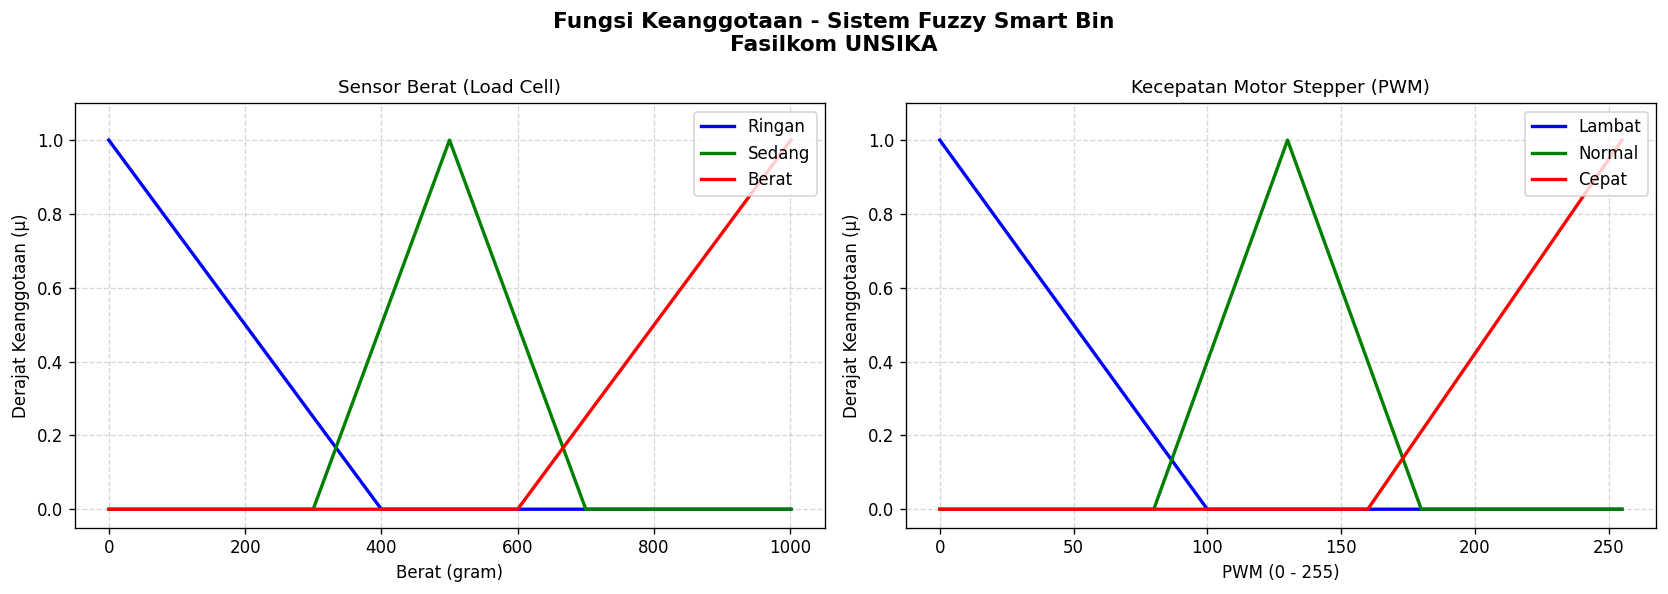


Grafik berhasil ditampilkan dan disimpan sebagai 'fuzzy_membership.png'!


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fungsi Keanggotaan - Sistem Fuzzy Smart Bin\nFasilkom UNSIKA',
             fontsize=13, fontweight='bold')

# --- Grafik 1: Fungsi Keanggotaan Berat Sampah ---
ax1.plot(berat_sampah.universe,
         fuzz.trimf(berat_sampah.universe, [0, 0, 400]),
         'b-', linewidth=2, label='Ringan')
ax1.plot(berat_sampah.universe,
         fuzz.trimf(berat_sampah.universe, [300, 500, 700]),
         'g-', linewidth=2, label='Sedang')
ax1.plot(berat_sampah.universe,
         fuzz.trimf(berat_sampah.universe, [600, 1001, 1001]),
         'r-', linewidth=2, label='Berat')

ax1.set_title('Sensor Berat (Load Cell)', fontsize=11)
ax1.set_xlabel('Berat (gram)')
ax1.set_ylabel('Derajat Keanggotaan (μ)')
ax1.legend(loc='upper right')
ax1.set_ylim(-0.05, 1.1)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Grafik 2: Fungsi Keanggotaan Kecepatan Motor ---
ax2.plot(kecepatan_motor.universe,
         fuzz.trimf(kecepatan_motor.universe, [0, 0, 100]),
         'b-', linewidth=2, label='Lambat')
ax2.plot(kecepatan_motor.universe,
         fuzz.trimf(kecepatan_motor.universe, [80, 130, 180]),
         'g-', linewidth=2, label='Normal')
ax2.plot(kecepatan_motor.universe,
         fuzz.trimf(kecepatan_motor.universe, [160, 255, 255]),
         'r-', linewidth=2, label='Cepat')

ax2.set_title('Kecepatan Motor Stepper (PWM)', fontsize=11)
ax2.set_xlabel('PWM (0 - 255)')
ax2.set_ylabel('Derajat Keanggotaan (μ)')
ax2.legend(loc='upper right')
ax2.set_ylim(-0.05, 1.1)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fuzzy_membership.png', bbox_inches='tight')
plt.show()
print("\nGrafik berhasil ditampilkan dan disimpan sebagai 'fuzzy_membership.png'!")

Uji Sistem dengan Berbagai Nilai Input

In [ ]:
print("\n" + "=" * 55)
print("=== UJI SISTEM FUZZY DENGAN BERBAGAI INPUT BERAT ===")
print("=" * 55)
print(f"{'Berat (gram)':<16} {'Kecepatan Motor (PWM)':<24} {'Kategori'}")
print("-" * 55)

test_inputs = [50, 200, 350, 500, 650, 800, 950]

for berat_val in test_inputs:
    simulasi.input['berat_sampah'] = berat_val
    simulasi.compute()
    pwm_out = simulasi.output['kecepatan_motor']

    if pwm_out < 100:
        kategori = "Lambat"
    elif pwm_out < 180:
        kategori = "Normal"
    else:
        kategori = "Cepat"

    print(f"{berat_val:<16} {pwm_out:<24.2f} {kategori}")

print("\nSistem berjalan dengan baik!")
print("Motor stepper bergerak lebih lambat saat menangani sampah berat,")
print("dan lebih cepat saat sampah ringan — menjaga presisi dan keawetan gir.")


=== UJI SISTEM FUZZY DENGAN BERBAGAI INPUT BERAT ===
Berat (gram)     Kecepatan Motor (PWM)    Kategori
-------------------------------------------------------
50               222.89                   Cepat
200              218.06                   Cepat
350              156.52                   Normal
500              130.00                   Normal
650              101.57                   Normal
800              38.91                    Lambat
950              33.81                    Lambat

Sistem berjalan dengan baik!
Motor stepper bergerak lebih lambat saat menangani sampah berat,
dan lebih cepat saat sampah ringan — menjaga presisi dan keawetan gir.
